In [1]:
# Multilayer Perceptron
import pandas as pd
import numpy
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)
import tensorflow as tf



import tensorflow.keras
import math
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2DTranspose,Input, Reshape, Conv2D, Flatten, Activation, LeakyReLU
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import concatenate, BatchNormalization
import argparse
#from tensorflow.keras.utils.np_utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dropout
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.stats import pearsonr, spearmanr
from skimage import io

In [2]:
####################
####### Functions #############
####################

def custom_loss_2 (y_true, y_pred):
    A = tensorflow.keras.losses.mean_absolute_error(y_true, y_pred)
    #B = keras.losses.categorical_crossentropy(y_true[:,-4:], y_pred[:,-4:])
    return A





def lrelu(x): #from pix2pix code
    a=0.2
    # adding these together creates the leak part and linear part
    # then cancels them out by subtracting/adding an absolute value term
    # leak: a*x/2 - a*abs(x)/2
    # linear: x/2 + abs(x)/2

    # this block looks like it has 2 inputs on the graph unless we do this
    x = tf.identity(x)
    return (0.5 * (1 + a)) * x + (0.5 * (1 - a)) * tf.abs(x)

def lrelu_output_shape(input_shape):
    shape = list(input_shape)
    return tuple(shape)

from tensorflow.keras.layers import Lambda
layer_lrelu=Lambda(lrelu, output_shape=lrelu_output_shape, name='Leaky_ReLU')


def createOutputLabels(Labels):
    output=np.zeros(shape=(len(Labels),12))    
    
    for i in range(len(Labels)):
        for j in range (4):
            if Labels.iloc[i,j]=='CN':
                output[i,j*3]=1
                output[i,j*3+1]=0
                output[i,j*3+2]=0

                
            elif Labels.iloc[i,j]=='MCI':
                output[i,j*3]=0
                output[i,j*3+1]=1
                output[i,j*3+2]=0
                
            elif Labels.iloc[i,j]=='AD':
                output[i,j*3]=0
                output[i,j*3+1]=0
                output[i,j*3+2]=1
                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output

def create_image(labels):
    output=np.zeros(shape=(len(labels),3,4,3))    
    
    for i in range(len(labels)):
        for j in range (3):
                if j ==0:
                    output[i,j,:,1] = labels[i,j]
                elif j==1:
                     output[i,j,:,2] = labels[i,j]
                elif j ==2:
                    output[i,j,:,0] = labels[i,j]

                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output



def FnCreateValidLabes(Labels):
    return range(len(Labels))

In [3]:
n_splits=10


In [3]:
####################
###### Reading Data ##############    
####################    

# AllDataset = pandas.read_csv('Data_XY_BLD_CutOff.csv', low_memory=False)
AllDataset = pd.read_csv('dataset_imputed_outlier_removed_final.csv', low_memory=False)
AllDataset = AllDataset.set_index(AllDataset.ID)

OriginalDataset = pd.read_excel('dataset_final.xlsx')
OriginalDataset = OriginalDataset.set_index(OriginalDataset.ID)

In [26]:
len(AllDataset)

5593

In [4]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [5]:
import pandas as pd

regions = ['Ventricles/ICV', 'Hippocampus/ICV', 'WholeBrain/ICV', 'Entorhinal/ICV', 'Fusiform/ICV', 'MidTemp/ICV',
           'FDG', 'AV45',
           'CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting','RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR','TRABSCOR',
           'ABETA', 'PTAU', 'TAU', 'AGE', 'PTEDUCAT', 'APOE4']
dx_order = ['CN', 'MCI', 'AD']  # Desired DX order

# Collect stats
summary_rows = []

for dx, group in AllDataset.groupby('DX'):
    for region in regions:
        values = group[region]
        summary_rows.append({
            'Region': region,
            'DX': dx,
            'mean': values.mean(),
            'q1': values.quantile(0.25),
            'q2': values.median(),
            'q3': values.quantile(0.75)
        })

# Create DataFrame
summary_df = pd.DataFrame(summary_rows)

# Convert DX to categorical with order
summary_df['DX'] = pd.Categorical(summary_df['DX'], categories=dx_order, ordered=True)

# Sort by Region, then DX
summary_df = summary_df.sort_values(by=['Region', 'DX'])

# Set MultiIndex and round
summary_df.set_index(['Region', 'DX'], inplace=True)
summary_df = summary_df.round(4)

# Show the final result
print(summary_df)


                        mean       q1        q2        q3
Region         DX                                        
ABETA          CN  1203.8133 831.3000 1270.0000 1689.2632
               MCI  972.9944 613.3500  845.8000 1359.8750
               AD   634.8277 445.0500  567.5500  735.4500
AGE            CN    76.3224  72.4000   76.3000   80.4000
               MCI   74.5346  69.1000   74.8000   80.3000
...                      ...      ...       ...       ...
Ventricles/ICV MCI    0.0261   0.0166    0.0238    0.0332
               AD     0.0339   0.0240    0.0318    0.0416
WholeBrain/ICV CN     0.6717   0.6383    0.6732    0.7025
               MCI    0.6663   0.6277    0.6637    0.7060
               AD     0.6229   0.5906    0.6199    0.6528

[75 rows x 4 columns]


In [6]:
regions = ['Ventricles/ICV', 'Hippocampus/ICV', 'WholeBrain/ICV', 'Entorhinal/ICV', 'Fusiform/ICV', 'MidTemp/ICV',
           'FDG', 'AV45',
           'CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting','RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR','TRABSCOR',
           'ABETA', 'PTAU', 'TAU', 'AGE', 'PTEDUCAT', 'APOE4']
targets = ['DX', 'DX6', 'DX12', 'DX24']
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )
X = AllDataset[regions]
y = AllDataset[targets]

id = AllDataset.ID

RF_X_gender = AllDataset.loc[:,['PTGENDER']]
RF_X_gender[RF_X_gender=='Male']=1
RF_X_gender[RF_X_gender=='Female']=2
RF_X_gender=RF_X_gender.fillna(3)

X = pd.concat([X, RF_X_gender], axis=1)

In [7]:
########################################
############## genreating input outputs from data #######
########################################

TargetTensors=createOutputLabels(y)
Y_all_tensors=TargetTensors
X_all_IDs=id.values

In [8]:
Y_all_tensors

array([[1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.]])

In [9]:
from tensorflow.keras import backend as K

def grouped_softmax(x):
    """
    Activation function that applies softmax separately to groups of neurons
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        x: Input tensor
        
    Returns:
        Tensor with grouped softmax applied
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    group_outputs = []
    
    # Apply softmax to each group
    for start, end in groups:
        group = x[..., start:end]
        group_softmax = K.softmax(group, axis=-1)
        group_outputs.append(group_softmax)
    
    # Concatenate all groups back together
    return K.concatenate(group_outputs, axis=-1)

In [10]:
######################################################################################
################## NEtwork Architecture ##################################################
##########################################################################################

####################################### MRI FCN ###############################################


# mri FCN

def create_model():
    MRI_inp_dim = 6
    MRI_visible = Input(shape=(MRI_inp_dim,), name='MRI')
    hiddenMRI1 = Dense(32)(MRI_visible)
    # hiddenMRI1 = LeakyReLU(alpha=0.5)(hiddenMRI1)
    hiddenMRI1 = Activation('relu')(hiddenMRI1)
    hiddenMRI1 = Dropout(0.2)(hiddenMRI1)
    hiddenMRI2 = Dense(64)(hiddenMRI1)
    # hiddenMRI2 = LeakyReLU(alpha=0.2)(hiddenMRI2)
    hiddenMRI2 = Activation('relu')(hiddenMRI2)
    hiddenMRI2 = Dropout(0.2)(hiddenMRI2)
    MRI_output = Dense(128, activation='relu')(hiddenMRI2)

    ####################################### PET FCN ###############################################
    PET_inp_dim = 2
    PET_visible = Input(shape=(PET_inp_dim,), name='PET')
    hiddenPET1 = Dense(32)(PET_visible)
    # hiddenPET1 = LeakyReLU(alpha=0.5)(hiddenPET1)
    hiddenPET1 = Activation('relu')(hiddenPET1)
    hiddenPET1 = Dropout(0.2)(hiddenPET1)
    hiddenPET2 = Dense(64)(hiddenPET1)
    # hiddenPET2 = LeakyReLU(alpha=0.2)(hiddenPET2)
    hiddenPET2 = Activation('relu')(hiddenPET2)
    hiddenPET2 = Dropout(0.2)(hiddenPET2)
    PET_output = Dense(128, activation='relu')(hiddenPET2)

    ####################################### COG FCN ###############################################
    # mri FCN
    COG_inp_dim = 11
    COG_visible = Input(shape=(COG_inp_dim,), name='COG')
    hiddenCOG1 = Dense(32)(COG_visible)
    # hiddenCOG1 = LeakyReLU(alpha=0.5)(hiddenCOG1)
    hiddenCOG1 = Activation('relu')(hiddenCOG1)
    hiddenCOG1 = Dropout(0.2)(hiddenCOG1)
    hiddenCOG2 = Dense(64)(hiddenCOG1)
    # hiddenCOG2 = LeakyReLU(alpha=0.2)(hiddenCOG2)
    hiddenCOG2 = Activation('relu')(hiddenCOG2)
    hiddenCOG2 = Dropout(0.2)(hiddenCOG2)
    COG_output = Dense(128, activation='relu')(hiddenCOG2)

    ####################################### CSF FCN ###############################################
    CSF_inp_dim = 3
    CSF_visible = Input(shape=(CSF_inp_dim,), name='CSF')
    hiddenCSF1 = Dense(32)(CSF_visible)
    # hiddenCSF1 = LeakyReLU(alpha=0.5)(hiddenCSF1)
    hiddenCSF1 = Activation('relu')(hiddenCSF1)
    hiddenCSF1 = Dropout(0.2)(hiddenCSF1)
    hiddenCSF2 = Dense(64)(hiddenCSF1)
    # hiddenCSF2 = LeakyReLU(alpha=0.2)(hiddenCSF2)
    hiddenCSF2 = Activation('relu')(hiddenCSF2)
    hiddenCSF2 = Dropout(0.2)(hiddenCSF2)
    CSF_output = Dense(128, activation='relu')(hiddenCSF2)

    ####################################### RF FCN ###############################################
    RF_inp_dim = 4
    RF_visible = Input(shape=(RF_inp_dim,), name='RF')
    hiddenRF1 = Dense(32)(RF_visible)
    # hiddenRF1 = LeakyReLU(alpha=0.5)(hiddenRF1)
    hiddenRF1 = Activation('relu')(hiddenRF1)
    hiddenRF1 = Dropout(0.2)(hiddenRF1)
    hiddenRF2 = Dense(64)(hiddenRF1)
    # hiddenRF2 = LeakyReLU(alpha=0.2)(hiddenRF2)
    hiddenRF2 = Activation('relu')(hiddenRF2)
    hiddenRF2 = Dropout(0.2)(hiddenRF2)
    RF_output = Dense(128, activation='relu')(hiddenRF2)

    #################################### Concat FCN ###############################################

    merge = concatenate([MRI_output, PET_output, COG_output, CSF_output,RF_output])
    merge = BatchNormalization()(merge)
    merge = Activation('relu')(merge)
    merge = Dropout(0.15)(merge)
    # interpretation layer
    # hidden1 = Dense(512, activation='relu')(merge)
    # hidden1 = Dropout(0.15)(hidden1)

    hidden2 = Dense(256, activation='relu')(merge)
    hidden2 = Dropout(0.2)(hidden2)

    hidden3 = Dense(128, activation='relu')(hidden2)
    hidden3 = Dropout(0.2)(hidden3)

    hidden4 = Dense(64)(hidden3)
    # hidden4 = BatchNormalization()(hidden4)
    hidden4 = Activation('relu')(hidden4)
    hidden4 = Dropout(0.25)(hidden4)

    hidden5 = Dense(32, activation='relu')(hidden4)
    hidden5 = Dropout(0.25)(hidden5)

    output = Dense(12, activation = grouped_softmax)(hidden5)
    model_tensorization=Model(inputs= [MRI_visible, PET_visible, COG_visible, CSF_visible, RF_visible], outputs=output)  
    return model_tensorization


model_tensorization = create_model()
model_tensorization.summary()
#dot_img_file = 'Network_23x23.png'


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 MRI (InputLayer)               [(None, 6)]          0           []                               
                                                                                                  
 PET (InputLayer)               [(None, 2)]          0           []                               
                                                                                                  
 COG (InputLayer)               [(None, 11)]         0           []                               
                                                                                                  
 CSF (InputLayer)               [(None, 3)]          0           []                               
                                                                                              

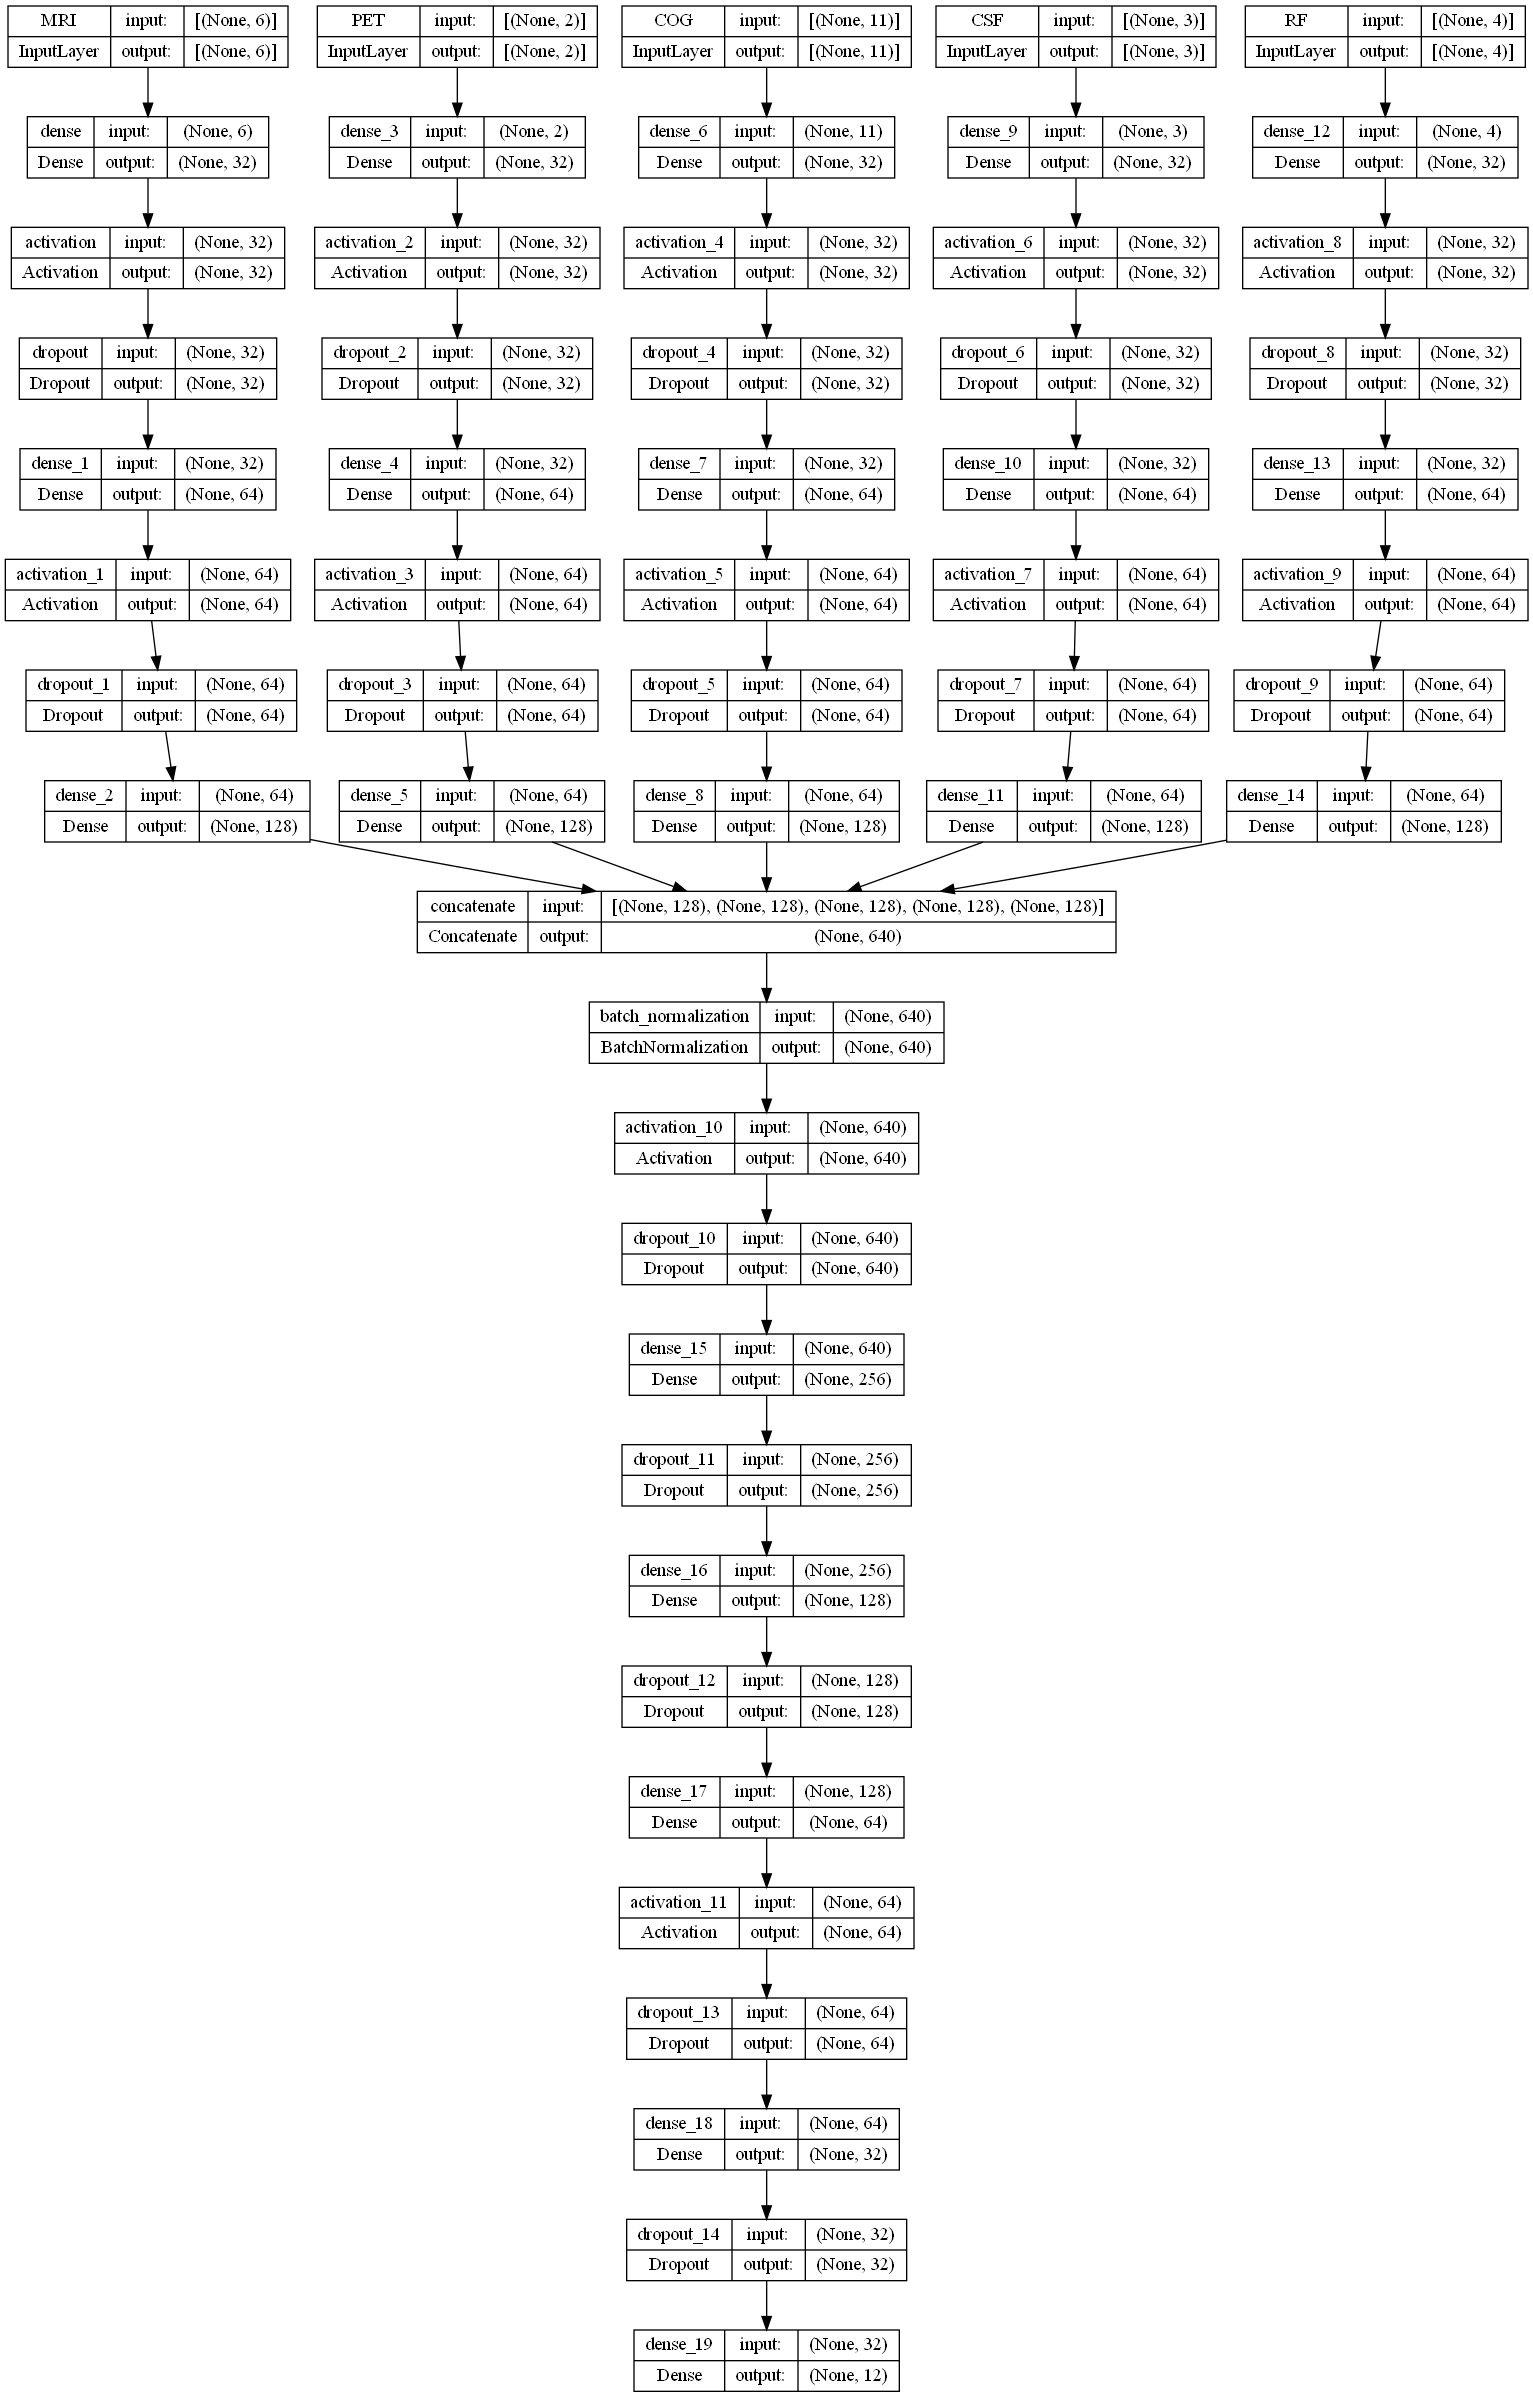

In [11]:
from tensorflow.keras.utils import plot_model

# Save the model architecture as a PNG file
plot_model(model_tensorization, to_file='model_tree.png', show_shapes=True, show_layer_names=True)

In [12]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

def grouped_categorical_crossentropy(y_true, y_pred):
    """
    Custom loss function that calculates average categorical cross entropy for groups of outputs.
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        y_true: Ground truth values, shape (batch_size, num_classes)
        y_pred: Predicted values, shape (batch_size, num_classes)
        
    Returns:
        Average of categorical cross entropy losses across the groups
    """
    # Initialize categorical cross entropy loss function
    cce = CategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    
    # Define groups of indices
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    
    # Compute CCE loss for each group
    group_losses = []
    for start, end in groups:
        loss = cce(y_true[..., start:end], y_pred[..., start:end])
        group_losses.append(loss)
    
    # Stack losses and compute the mean across groups
    all_losses = tf.stack(group_losses, axis=-1)  # Shape: (batch_size, num_groups)
    mean_loss_per_sample = tf.reduce_mean(all_losses, axis=-1)  # Mean across groups

    # Final mean across the batch
    final_loss = tf.reduce_mean(mean_loss_per_sample)  
    
    return final_loss


In [13]:
import tensorflow as tf

def grouped_categorical_accuracy(y_true, y_pred):
    """
    Computes average categorical accuracy for grouped outputs:
    Groups: [0-2], [3-5], [6-8], [9-11]
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    accuracies = []

    for start, end in groups:
        true_group = y_true[..., start:end]
        pred_group = y_pred[..., start:end]

        # Convert one-hot to class indices
        true_labels = tf.argmax(true_group, axis=-1)
        pred_labels = tf.argmax(pred_group, axis=-1)

        acc = tf.cast(tf.equal(true_labels, pred_labels), tf.float32)
        accuracies.append(acc)

    # Stack group accuracies and compute mean per sample
    all_accuracies = tf.stack(accuracies, axis=-1)  # (batch_size, num_groups)
    mean_accuracy = tf.reduce_mean(all_accuracies, axis=-1)  # Mean per sample

    # Final mean across batch
    return tf.reduce_mean(mean_accuracy)


In [14]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import random
import time
import os

In [ ]:


# Number of folds
num_folds = 10

# Directory to save best models
os.makedirs("saved_models_kfold", exist_ok=True)

# K-Fold cross-validator
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# For tracking performance
fold_accuracies = []
fold_losses = []
all_histories = []

# K-Fold loop
for fold, (train_idx, test_idx) in enumerate(kfold.split(X)):
    print(f'\n=== Training Fold {fold + 1} ===')

    # Shuffle with fixed seed for reproducibility
    random.seed(11)  # You can choose any seed value
    random.shuffle(train_idx)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    # Initialize and fit scaler on training data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    Y_train_fold=Y_all_tensors[train_idx]
    Y_val_fold = Y_all_tensors[test_idx]

    X_train_fold = [X_train_scaled[:,:6], X_train_scaled[:,6:8], X_train_scaled[:,8:19], X_train_scaled[:,19:22], X_train_scaled[:,22:26]]
    X_val_fold = [X_test_scaled[:,:6], X_test_scaled[:,6:8], X_test_scaled[:,8:19], X_test_scaled[:,19:22], X_test_scaled[:,22:26]]

    

    # Reinitialize a fresh model instance
    model = create_model()
    model.compile(loss=grouped_categorical_crossentropy,
                  optimizer='adam',
                  metrics=[grouped_categorical_accuracy])

    # Define callbacks
    model_path = f"saved_models_kfold/best_model_fold_{fold+1}.h5"
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        model_path, monitor='val_loss', save_best_only=True, verbose=1)
    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1)
    early_stop_cb = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)

    # Train the model
    start_time = time.time()
    history = model.fit(
        X_train_fold, Y_train_fold,
        validation_split=0.1,
        epochs=600,
        batch_size=64,
        verbose=1,
        callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
    )
    elapsed_time = time.time() - start_time
    print(f'--- Fold {fold + 1} training time: {elapsed_time:.2f} seconds')

    # Evaluate the best model
    best_model = tf.keras.models.load_model(model_path,
                                            custom_objects={
                                                'grouped_categorical_crossentropy': grouped_categorical_crossentropy,
                                                'grouped_categorical_accuracy': grouped_categorical_accuracy,
                                                'grouped_softmax': grouped_softmax
                                            })
    val_loss, val_accuracy = best_model.evaluate(X_val_fold, Y_val_fold, verbose=0)
    fold_losses.append(val_loss)
    fold_accuracies.append(val_accuracy)

    # Store history
    all_histories.append(history.history)

# Print cross-validation summary
print('\n=== Cross-Validation Summary ===')
print(f'Average Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}')
print(f'Average Loss: {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}')



=== Training Fold 1 ===
Epoch 1/600


KeyboardInterrupt: 

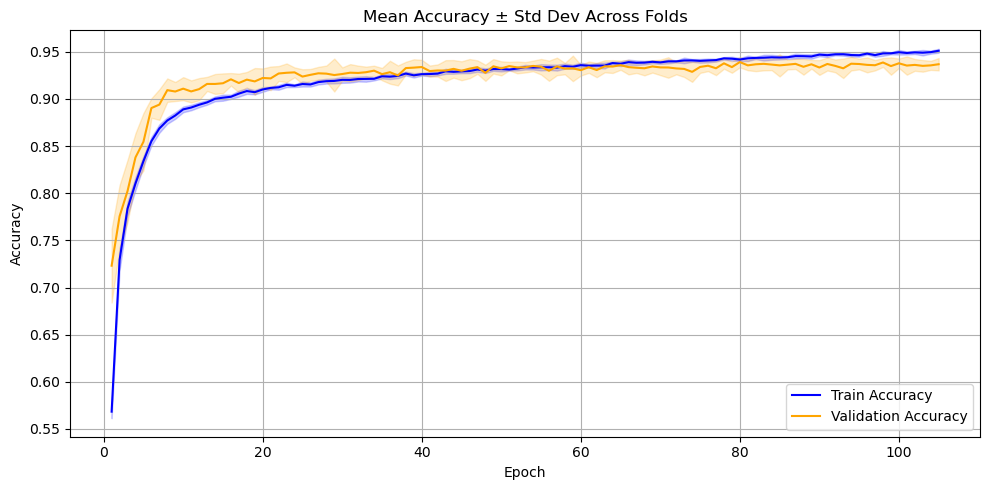

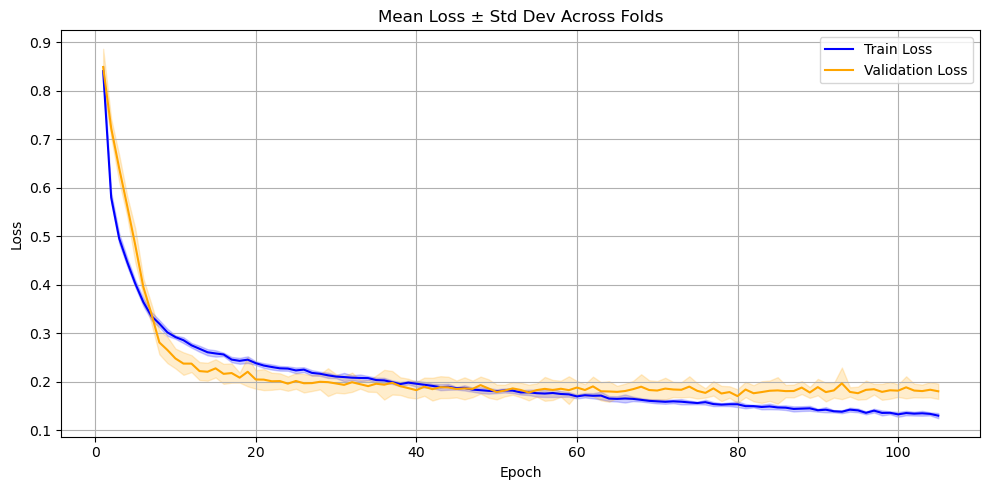

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Get the minimum number of epochs across all folds (due to early stopping)
min_epochs = min(len(h['loss']) for h in all_histories)

# Stack metrics
train_acc = np.array([h['grouped_categorical_accuracy'][:min_epochs] for h in all_histories])
val_acc   = np.array([h['val_grouped_categorical_accuracy'][:min_epochs] for h in all_histories])
train_loss = np.array([h['loss'][:min_epochs] for h in all_histories])
val_loss   = np.array([h['val_loss'][:min_epochs] for h in all_histories])

epochs = np.arange(1, min_epochs + 1)

# Accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc.mean(axis=0), label='Train Accuracy', color='blue')
plt.fill_between(epochs, train_acc.mean(axis=0) - train_acc.std(axis=0),
                 train_acc.mean(axis=0) + train_acc.std(axis=0), alpha=0.2, color='blue')
plt.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy', color='orange')
plt.fill_between(epochs, val_acc.mean(axis=0) - val_acc.std(axis=0),
                 val_acc.mean(axis=0) + val_acc.std(axis=0), alpha=0.2, color='orange')
plt.title('Mean Accuracy ± Std Dev Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss.mean(axis=0), label='Train Loss', color='blue')
plt.fill_between(epochs, train_loss.mean(axis=0) - train_loss.std(axis=0),
                 train_loss.mean(axis=0) + train_loss.std(axis=0), alpha=0.2, color='blue')
plt.plot(epochs, val_loss.mean(axis=0), label='Validation Loss', color='orange')
plt.fill_between(epochs, val_loss.mean(axis=0) - val_loss.std(axis=0),
                 val_loss.mean(axis=0) + val_loss.std(axis=0), alpha=0.2, color='orange')
plt.title('Mean Loss ± Std Dev Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
from sklearn.model_selection import train_test_split
import random



reserved_idx = [1872, 1073, 2378, 3357, 4187, 4288, 4425, 4429, 5021]

idx = [i for i in range(len(Y_all_tensors)) if i not in reserved_idx]

temp_idx, test_idx = train_test_split(idx, test_size=0.1, shuffle=True, random_state=11)
train_idx, val_idx = train_test_split(temp_idx, test_size=0.1, shuffle=True,  random_state=11)

test_idx = test_idx + reserved_idx
# Shuffle with fixed seed for reproducibility
# random.seed(42)  # You can choose any seed value
# random.shuffle(train_idx)


X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]


# Initialize and fit scaler on training data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

Y_train=Y_all_tensors[train_idx]
Y_test = Y_all_tensors[test_idx]
Y_val = Y_all_tensors[val_idx]

X_train = [X_train_scaled[:,:6], X_train_scaled[:,6:8], X_train_scaled[:,8:19], X_train_scaled[:,19:22], X_train_scaled[:,22:26]]
X_test = [X_test_scaled[:,:6], X_test_scaled[:,6:8], X_test_scaled[:,8:19], X_test_scaled[:,19:22], X_test_scaled[:,22:26]]
X_val = [X_val_scaled[:,:6], X_val_scaled[:,6:8], X_val_scaled[:,8:19], X_val_scaled[:,19:22], X_val_scaled[:,22:26]]
X_train_names=X_all_IDs[train_idx]
X_test_names=X_all_IDs[test_idx]
X_val_names=X_all_IDs[val_idx]
print(f"Training set size: {len(X_train[0])}")
print(f"Validation set size: {len(X_val[0])}")
print(f"Test set size: {len(X_test[0])}")

Training set size: 4522
Validation set size: 503
Test set size: 568


In [16]:
len(test_idx)

568

In [26]:
# Example column list
column_list = ["DX", "DX6", "DX12", "DX24"]

# Function to label if diagnosis changed
def label_dx_change(row):
    initial = row["DX"]
    # Check if any future timepoints are different from the initial
    changed = any(pd.notna(row[col]) and row[col] != initial for col in column_list[1:])
    return f"{initial}_c" if changed else initial

# Apply function to create a new column
dataset_copy = AllDataset.iloc[test_idx].copy()
dataset_copy["DX_status"] = dataset_copy.apply(label_dx_change, axis=1)

# Count each unique label
dx_status_counts = dataset_copy["DX_status"].value_counts()

print(dx_status_counts)

AD       228
MCI      145
CN       139
MCI_c     48
CN_c       7
AD_c       1
Name: DX_status, dtype: int64


In [17]:
X_test

,Ventricles/ICV,Hippocampus/ICV,WholeBrain/ICV,Entorhinal/ICV,Fusiform/ICV,MidTemp/ICV,FDG,AV45,CDRSB,MMSE,...,LDELTOTAL,DIGITSCOR,TRABSCOR,ABETA,PTAU,TAU,AGE,PTEDUCAT,APOE4,PTGENDER
ID,,,,,,,,,,,,,,,,,,,,,
5351,0.0372,0.0041,0.6411,0.0018,0.0097,0.0108,1.0546,1.3790,8.0000,9.0000,...,1.4466,26.9465,205.9441,634.8277,35.5371,362.4038,85.8000,20,1.0000,1
5407,0.0401,0.0048,0.7172,0.0034,0.0135,0.0147,1.3012,1.4759,0.0000,28.0000,...,10.0000,48.7124,81.0000,775.7000,19.5800,232.8000,80.4000,14,0.0000,1
3309,0.0138,0.0053,0.6852,0.0023,0.0105,0.0150,1.2885,0.9387,3.0000,22.0000,...,1.3818,22.0000,283.0000,972.9944,27.5313,287.9782,70.1000,12,0.0000,2
3501,0.0100,0.0050,0.7317,0.0025,0.0144,0.0143,1.2395,1.0028,1.0000,30.0000,...,18.0000,38.9430,72.0000,972.9944,27.5313,287.9782,69.7000,18,0.0000,2
3964,0.0339,0.0036,0.6229,0.0018,0.0097,0.0108,1.0546,1.5111,2.5000,25.0000,...,0.0000,26.9465,105.0000,634.8277,35.5371,362.4038,74.3000,16,2.0000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4188,0.0109,0.0046,0.7325,0.0018,0.0142,0.0140,1.4879,1.3756,0.0000,28.0000,...,15.0000,48.7124,73.0000,1700.0000,19.7000,232.0000,71.4000,18,0.0000,2
4289,0.0306,0.0033,0.6358,0.0014,0.0096,0.0103,1.2304,1.2601,1.5000,29.0000,...,6.0000,38.9430,45.0000,664.5000,26.3500,288.0000,71.3000,18,2.0000,1
4426,0.0219,0.0048,0.8026,0.0031,0.0146,0.0154,1.4433,1.2148,0.5000,29.0000,...,16.0000,48.7124,54.0000,1373.0000,30.5100,370.2000,70.8000,15,0.0000,2


In [28]:
import tensorflow as tf
import numpy as np
import time

# Define how many models you want in your ensemble
n_models = 25
ensemble_models = []

# Training loop for each model in the ensemble
for i in range(n_models):
    print(f"\nTraining model {i+1}/{n_models}...")
    
    # Clone a new instance of the base model
    model_tensorization = create_model()
    model_tensorization.compile(loss=grouped_categorical_crossentropy, 
                  optimizer='adam', 
                  metrics=[grouped_categorical_accuracy])
    
    callback_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True, verbose=1
    )
    callback_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1
    )

    start_time = time.time()
    model_tensorization.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=600, 
        batch_size=64,
        verbose=1, 
        callbacks=[callback_early_stop, callback_reduce_lr]
    )
    elapsed_time = time.time() - start_time
    print(f'Model {i+1} training time: {elapsed_time:.2f} seconds')
    
    # Save the trained model to the ensemble list
    ensemble_models.append(model_tensorization)



Training model 1/25...
Epoch 1/600
71/71 [==============================] - 6s 35ms/step - loss: 0.8546 - grouped_categorical_accuracy: 0.5725 - val_loss: 0.8633 - val_grouped_categorical_accuracy: 0.7834 - lr: 0.0010
Epoch 2/600
71/71 [==============================] - 1s 19ms/step - loss: 0.5887 - grouped_categorical_accuracy: 0.7372 - val_loss: 0.7497 - val_grouped_categorical_accuracy: 0.7557 - lr: 0.0010
Epoch 3/600
71/71 [==============================] - 2s 22ms/step - loss: 0.5061 - grouped_categorical_accuracy: 0.7855 - val_loss: 0.6908 - val_grouped_categorical_accuracy: 0.6968 - lr: 0.0010
Epoch 4/600
71/71 [==============================] - 1s 21ms/step - loss: 0.4416 - grouped_categorical_accuracy: 0.8197 - val_loss: 0.5924 - val_grouped_categorical_accuracy: 0.7813 - lr: 0.0010
Epoch 5/600
71/71 [==============================] - 2s 22ms/step - loss: 0.3756 - grouped_categorical_accuracy: 0.8491 - val_loss: 0.5245 - val_grouped_categorical_accuracy: 0.8006 - lr: 0.0010
E

In [35]:
import os

# Assuming ensemble_models is a list of Keras models
# and you want to save each model to a specific directory
save_dir = 'saved_models_8-6'
os.makedirs(save_dir, exist_ok=True)

for idx, model in enumerate(ensemble_models):
    model_path = os.path.join(save_dir, f'ensemble_model_{idx}.h5')
    model.save(model_path)
    print(f'Model {idx} saved to {model_path}')


Model 0 saved to saved_models_8-6\ensemble_model_0.h5
Model 1 saved to saved_models_8-6\ensemble_model_1.h5
Model 2 saved to saved_models_8-6\ensemble_model_2.h5
Model 3 saved to saved_models_8-6\ensemble_model_3.h5
Model 4 saved to saved_models_8-6\ensemble_model_4.h5
Model 5 saved to saved_models_8-6\ensemble_model_5.h5
Model 6 saved to saved_models_8-6\ensemble_model_6.h5
Model 7 saved to saved_models_8-6\ensemble_model_7.h5
Model 8 saved to saved_models_8-6\ensemble_model_8.h5
Model 9 saved to saved_models_8-6\ensemble_model_9.h5
Model 10 saved to saved_models_8-6\ensemble_model_10.h5
Model 11 saved to saved_models_8-6\ensemble_model_11.h5
Model 12 saved to saved_models_8-6\ensemble_model_12.h5
Model 13 saved to saved_models_8-6\ensemble_model_13.h5
Model 14 saved to saved_models_8-6\ensemble_model_14.h5
Model 15 saved to saved_models_8-6\ensemble_model_15.h5
Model 16 saved to saved_models_8-6\ensemble_model_16.h5
Model 17 saved to saved_models_8-6\ensemble_model_17.h5
Model 18 sav

In [19]:
import os
from tensorflow.keras.models import load_model

# Directory where models are saved
load_dir = 'saved_models'

# Load models into a list
ensemble_models = []
model_files = sorted([f for f in os.listdir(load_dir) if f.endswith('.h5')])

for model_file in model_files:
    model_path = os.path.join(load_dir, model_file)
    model = load_model(model_path, custom_objects={
                                                'grouped_categorical_crossentropy': grouped_categorical_crossentropy,
                                                'grouped_categorical_accuracy': grouped_categorical_accuracy,
                                                'grouped_softmax': grouped_softmax
                                            }                                               
                                            )
    ensemble_models.append(model)
    print(f'Loaded model from {model_path}')


Loaded model from saved_models\ensemble_model_0.h5
Loaded model from saved_models\ensemble_model_1.h5
Loaded model from saved_models\ensemble_model_10.h5
Loaded model from saved_models\ensemble_model_11.h5
Loaded model from saved_models\ensemble_model_12.h5
Loaded model from saved_models\ensemble_model_13.h5
Loaded model from saved_models\ensemble_model_14.h5
Loaded model from saved_models\ensemble_model_15.h5
Loaded model from saved_models\ensemble_model_16.h5
Loaded model from saved_models\ensemble_model_17.h5
Loaded model from saved_models\ensemble_model_18.h5
Loaded model from saved_models\ensemble_model_19.h5
Loaded model from saved_models\ensemble_model_2.h5
Loaded model from saved_models\ensemble_model_20.h5
Loaded model from saved_models\ensemble_model_21.h5
Loaded model from saved_models\ensemble_model_22.h5
Loaded model from saved_models\ensemble_model_23.h5
Loaded model from saved_models\ensemble_model_24.h5
Loaded model from saved_models\ensemble_model_3.h5
Loaded model fro

In [29]:
from sklearn.metrics import accuracy_score
import numpy as np

def evaluate_models(models, X_test, Y_test):
    model_accuracies = []
    model_losses = []
    
    for i, model in enumerate(models):
        # Get predictions
        loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

        print(f"Model {i+1}: Accuracy = {accuracy:.4f}, Loss = {loss:.4f}")

    return model_accuracies, model_losses


In [30]:
evaluate_models(ensemble_models, X_test, Y_test)

Model 1: Accuracy = 0.9323, Loss = 0.1581
Model 2: Accuracy = 0.9397, Loss = 0.1462
Model 3: Accuracy = 0.9314, Loss = 0.1627
Model 4: Accuracy = 0.9359, Loss = 0.1538
Model 5: Accuracy = 0.9293, Loss = 0.1579
Model 6: Accuracy = 0.9437, Loss = 0.1485
Model 7: Accuracy = 0.9337, Loss = 0.1612
Model 8: Accuracy = 0.9444, Loss = 0.1498
Model 9: Accuracy = 0.9384, Loss = 0.1484
Model 10: Accuracy = 0.9317, Loss = 0.1586
Model 11: Accuracy = 0.9355, Loss = 0.1488
Model 12: Accuracy = 0.9387, Loss = 0.1428
Model 13: Accuracy = 0.9339, Loss = 0.1581
Model 14: Accuracy = 0.9392, Loss = 0.1550
Model 15: Accuracy = 0.9411, Loss = 0.1470
Model 16: Accuracy = 0.9352, Loss = 0.1493
Model 17: Accuracy = 0.9378, Loss = 0.1471
Model 18: Accuracy = 0.9400, Loss = 0.1605
Model 19: Accuracy = 0.9460, Loss = 0.1491
Model 20: Accuracy = 0.9282, Loss = 0.1529
Model 21: Accuracy = 0.9427, Loss = 0.1531
Model 22: Accuracy = 0.9363, Loss = 0.1522
Model 23: Accuracy = 0.9358, Loss = 0.1441
Model 24: Accuracy =

([], [])

In [31]:
def ensemble_predict_with_uncertainty(models, X_input, Y_test):
    # Collect all model predictions
    all_preds = np.array([model.predict(X_input) for model in models])  # Shape: (n_models, n_samples, n_classes)
    
    # Mean prediction (ensemble output)
    mean_preds = np.mean(all_preds, axis=0)  # Shape: (n_samples, n_classes)
    
    # Predictive uncertainty: variance across model outputs
    uncertainty = np.var(all_preds, axis=0)  # Shape: (n_samples, n_classes)
    
    return mean_preds, uncertainty


In [32]:
# Get predictions and uncertainties on test data
Y_pred_ensemble, Y_uncertainty = ensemble_predict_with_uncertainty(ensemble_models, X_test, Y_test)

# # For each sample, get the predicted class and uncertainty for that class
# predicted_classes = np.argmax(Y_pred_ensemble, axis=1)
# uncertainty_scores = np.take_along_axis(Y_uncertainty, np.expand_dims(predicted_classes, axis=1), axis=1).squeeze()

# # Print example
# for i in range(5):
#     print(f"Sample {i}: predicted class = {predicted_classes[i]}, uncertainty = {uncertainty_scores[i]:.4f}")


18/18 [==============================] - 0s 5ms/step


In [56]:
mask = (
    (Y_test[:, 0] == 1) &
    (Y_test[:, 3] == 1) &
    (Y_test[:, 6] == 1) &
    (Y_test[:, 9] == 1)
) | (
    (Y_test[:, 1] == 1) &
    (Y_test[:, 4] == 1) &
    (Y_test[:, 7] == 1) &
    (Y_test[:, 10] == 1)
) | (
    (Y_test[:, 2] == 1) &
    (Y_test[:, 5] == 1) &
    (Y_test[:, 8] == 1) &
    (Y_test[:, 11] == 1)
)

Y_test_stable = Y_test[mask]
Y_pred_stable = Y_pred_ensemble[mask]
Y_uncertainty_stable = Y_uncertainty[mask]
print(f"Number of stable samples: {len(Y_test_stable)}")
print(grouped_categorical_accuracy(Y_test_stable, Y_pred_stable))

# Assuming y is your input array of shape (568, 12)
# Step 1: Reshape to (568, 4, 3)
Y_uncertainty_stable_reshaped = Y_uncertainty_stable.reshape(-1, 4, 3)

# Step 2: Take max along the last axis (axis=2), resulting in shape (568, 4)
max_values = np.max(Y_uncertainty_stable_reshaped, axis=2)
max_var = np.max(max_values, axis=1)

# Step 3: Average over all 568 rows for each of the 4 chunks
average_max = np.mean(max_values)
print("Average max values:", average_max)

threshold =  0.0076 #0.0161 #0.02574
np.sum(max_var < threshold)
print("% above threshold:", (np.sum(max_var < threshold) / len(max_var)) * 100)

Number of stable samples: 512
tf.Tensor(0.97021484, shape=(), dtype=float32)
Average max values: 0.004002832
% above threshold: 80.859375


In [ ]:
Y_test_conv = Y_test[~mask]
Y_pred_conv = Y_pred_ensemble[~mask]
Y_uncertainty_conv = Y_uncertainty[~mask]
print(f"Number of conv samples: {len(Y_test_conv)}")
print(grouped_categorical_accuracy(Y_test_conv, Y_pred_conv))

# Assuming y is your input array of shape (568, 12)
# Step 1: Reshape to (568, 4, 3)
Y_uncertainty_conv_reshaped = Y_uncertainty_conv.reshape(-1, 4, 3)

# Step 2: Take max along the last axis (axis=2), resulting in shape (568, 4)
max_values = np.max(Y_uncertainty_conv_reshaped, axis=2)
max_var = np.max(max_values, axis=1)

# Step 3: Average over all 568 rows for each of the 4 chunks
average_max = np.mean(max_values)
print("Average max values:", average_max)

threshold =  0.0257
np.sum(max_var < threshold)
print("% above threshold:", (np.sum(max_var < threshold) / len(max_var)) * 100)

Number of conv samples: 56
tf.Tensor(0.7276786, shape=(), dtype=float32)
Average max values: 0.016620535
% above threshold: 67.85714285714286


In [64]:
test_all_data = AllDataset.iloc[test_idx]
test_all_data[~mask].to_csv('test_convetable_data.csv', index=False)

In [61]:
AllDataset.iloc[test_idx].to_csv('test_all_data.csv', index=False)

In [36]:
grouped_categorical_accuracy(Y_test, Y_pred_ensemble)

<tf.Tensor: shape=(), dtype=float32, numpy=0.94630283>

In [47]:
Y_uncertainty[0]

array([0.0000000e+00, 2.1319837e-11, 2.1297098e-11, 0.0000000e+00,
       1.4648269e-11, 1.4669582e-11, 9.6556471e-40, 3.7388439e-12,
       3.7772450e-12, 1.9624442e-39, 3.3706555e-14, 3.9790393e-14],
      dtype=float32)

In [37]:
import numpy as np

# Assuming y is your input array of shape (568, 12)
# Step 1: Reshape to (568, 4, 3)
Y_uncertainty_reshaped = Y_uncertainty.reshape(-1, 4, 3)

# Step 2: Take max along the last axis (axis=2), resulting in shape (568, 4)
max_values = np.max(Y_uncertainty_reshaped, axis=2)

# Step 3: Average over all 568 rows for each of the 4 chunks
average_max = np.mean(max_values)

print("Average max values:", average_max)


Average max values: 0.00524799


In [49]:
max_values.shape

(568, 4)

In [50]:
max_var = np.max(max_values, axis=1)

In [51]:
max_var.shape

(568,)

In [38]:
threshold = 0.0161 #0.02574
np.sum(max_var > threshold)

25

In [66]:
568-85

483

In [40]:
import numpy as np

# Assuming Y_uncertainty is already defined
max_value = np.max(Y_uncertainty)
min_value = np.min(Y_uncertainty)

print("Maximum value:", max_value)
print("Minimum value:", min_value)

Maximum value: 0.097439855
Minimum value: 0.0


In [ ]:
# model_tensorization.save("model_tensorization_for_paper_05-01-2025.h5")

In [41]:
Y_test[0]

array([0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.])

In [42]:
y_true = np.reshape(Y_test,(len(Y_test),4,3)).transpose(0, 2, 1)
y_true[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 1., 1., 1.]])

In [43]:
Y_pred_ensemble = np.round(Y_pred_ensemble, 2)
y_pred = np.reshape(Y_pred_ensemble,(len(Y_pred_ensemble),4,3)).transpose(0, 2, 1)
y_pred[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 1., 1., 1.]], dtype=float32)

In [44]:
Y_uncertainty = np.round(Y_uncertainty, 4)
y_var = np.reshape(Y_uncertainty,(len(Y_uncertainty),4,3)).transpose(0, 2, 1)
y_var[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)

In [45]:
y_true_img = create_image(y_true)
y_true_img[2,:,:,:]


array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 1.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]])

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def plot_output(img, y, title, var=None):
    if var is None or np.isscalar(var):
        var = np.zeros_like(y)

    plt.imshow(img)
    plt.title(title)

    # Set x-axis ticks and labels
    x_ticks = [0, 1, 2, 3]
    x_labels = ["T0", "T6", "T12", "T24"]
    plt.xticks(x_ticks, x_labels)

    # Set y-axis ticks and labels
    y_ticks = [0, 1, 2]
    y_labels = ["CN", "MCI", "AD"]
    plt.yticks(y_ticks, y_labels)

    plt.ylim(2.5, -1)

    if title == "True":
        plt.axhspan(-1, -0.5, facecolor='gold', hatch='///', edgecolor='black', zorder=0)
    else:
        plt.axhspan(-1, -0.5, facecolor='gold', zorder=0)

    # Grid lines
    for x in range(1, len(x_ticks)):
        plt.axvline(x=x - 0.5, color='silver', linewidth=1)
    plt.axhline(y=0.495, color='gray', linestyle='--', linewidth=0.25)
    plt.axhline(y=1.495, color='gray', linestyle='--', linewidth=0.25)
    plt.axhline(y=-0.495, color='gray', linestyle='--', linewidth=0.25)

    # Show main label values
    for i in range(y.shape[1]):       # Time (x-axis)
        for j in range(y.shape[0]):   # Class (y-axis)
            label = y[j, i]
            if label is not None and label > 0:
                plt.text(i, j, f"{label:.2f}", color='white', fontsize=7, ha='center', va='center')

    # Safely reshape var to match (classes, timepoints)
    try:
        reshaped_var = var.reshape((3, -1))  # Assuming 3 classes
        for i in range(reshaped_var.shape[1]):  # Iterate over timepoints
            max_uncertainty = np.max(reshaped_var[:, i])
            if title != "True":
                plt.text(i, -0.75, f"{np.exp(-13.86*max_uncertainty):.2f}", color='black', fontsize=7, ha='center', va='center')
    except:
        print("Warning: Could not reshape or interpret 'var' for uncertainty strip.")

    # Set plot limits
    

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('silver')
        spine.set_linewidth(1)


In [47]:
y_true[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 1., 1., 1.]])

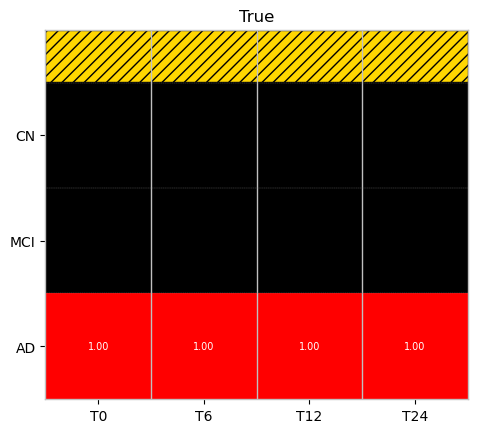

In [48]:
plot_output(y_true_img[0, :, :, :],y_true[0], "True" )

In [49]:
y_pred_img = create_image(y_pred)
y_pred_img[0,:,:,:]


array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]])

In [50]:
y_var[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)

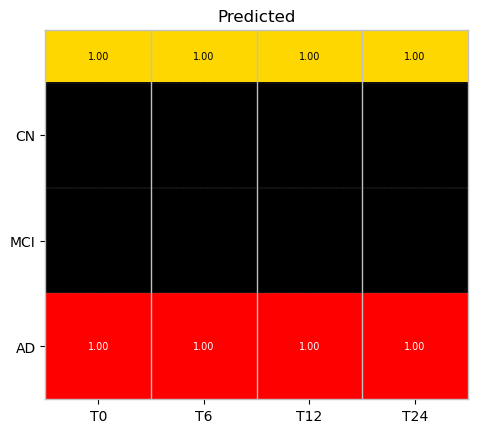

In [51]:
plot_output(y_pred_img[0,:,:,:],y_pred[0], "Predicted", y_var[0])

In [52]:
y_var[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)

C:\Users\14792\AppData\Local\Temp\ipykernel_34480\3812201786.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


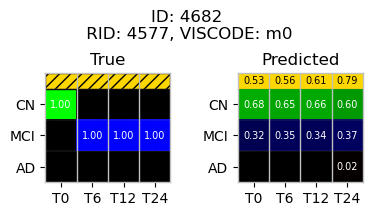

In [53]:
index = 15
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
id = X_test_names[index]
rid = AllDataset.loc[AllDataset['ID'] == X_test_names[index], 'RID'].values[0]
t_period = AllDataset.loc[AllDataset['ID'] == X_test_names[index], 'VISCODE'].values[0]
fig.suptitle(f"ID: {id}\n RID: {rid}, VISCODE: m{t_period}")

plt.sca(axes[0])
plot_output(y_true_img[index, :, :, :], y_true[index], "True")

plt.sca(axes[1])
plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted", y_var[index])

fig.tight_layout()  # reserve space for suptitle
fig.savefig(f"output_{id}.png", dpi=300, bbox_inches='tight')
fig.show()

In [54]:
for index in range(len(X_test_names)):
    fig, axes = plt.subplots(1, 2, figsize=(4,2))
    id = X_test_names[index]
    rid = AllDataset.loc[AllDataset['ID'] == X_test_names[index], 'RID'].values[0]
    t_period = AllDataset.loc[AllDataset['ID'] == X_test_names[index], 'VISCODE'].values[0]
    fig.suptitle(f"ID: {id}\n RID: {rid}, VISCODE: m{t_period}")

    plt.sca(axes[0])
    plot_output(y_true_img[index, :, :, :], y_true[index], "True")

    plt.sca(axes[1])
    plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted", y_var[index])
    
    fig.tight_layout()  # reserve space for suptitle
    fig.savefig(f"test_images_imputed_with_ensemble_8-6/{rid}_{t_period}.jpg", format='jpg', dpi=300, bbox_inches='tight')
    plt.close(fig)


In [115]:
a = np.array([[[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

aa = np.array([[1., 1., 1., 1.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

Vaa = np.array([[0, 0, 0, 0],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

b = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 1.],
            [0., 0., 1.],
            [0., 0., 1.],
            [0., 0., .97]],

           [[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [.03, 0., 0.]]])

bb = np.array([[0., 0., 0., 0.],
               [1., 1., 1., .97],
                [0., 0., 0., 0.03]])

Vbb = np.array([[0., 0., 0., 0.],
               [0, 0.0, .0, .001],
                [0., 0., 0., 0.]])


c = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[1., 0., 0.],
            [1., 0., 0.],
            [1., 0., 0.],
            [1., 0., 0.]]])

cc = np.array([[0., 0., 0., 0.],
                [0., 0., 0., 0.],
                [1., 1., 1., 1.],])

Vcc = np.array([[0., 0., 0., 0.],
                [0., 0., 0., 0.],
                [0, 0, 0., 0.],])

d = np.array([[[0., 1., 0.],
        [0., .75, 0.],
        [0., .48, 0.],
        [0., .05, 0.]],

       [[0., 0., 0.],
        [0., 0., .25],
        [0., 0., .52],
        [0., 0., .95]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

dd = np.array([[1., .75, .48, .05],
               [0., 0.25, .52, .95],
                [0., 0., 0., 0.],])
Vdd = np.array([[0, 0 , 0, .00],
               [0., 0.02, 0.01, 0],
                [0., 0., 0., 0.],])

e = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 1.],
            [0., 0., 0.9],
            [0., 0., 0.73],
            [0., 0., 0.65]],

           [[0., 0., 0.],
            [.1, 0., 0.],
            [.27, 0., 0.],
            [.35, 0., 0.]]])

ee = np.array([[0, 0 , 0., 0.],
               [1., 0.9, .73, .35],
                [0., 0.1, 0.27, .65],])

Vee = np.array([[0, 0 , 0., 0.],
               [0., 0.0, .0, .005],
                [0., 0.01, 0.027, 0],])

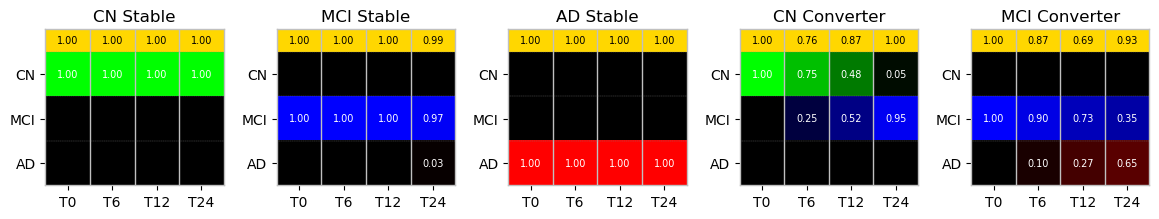

In [120]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(12, 6))

# First row
plt.sca(axes[0])
plot_output(a, aa, "CN Stable", Vaa)

plt.sca(axes[1])
plot_output(b, bb, "MCI Stable", Vbb)

plt.sca(axes[2])
plot_output(c, cc, "AD Stable", Vcc)

# Second row
plt.sca(axes[3])
plot_output(d, dd, "CN Converter", Vdd)

plt.sca(axes[4])
plot_output(e, ee, "MCI Converter", Vee)

# # Hide unused subplot
# axes[1,2].axis('off')

# # Improve spacing
plt.subplots_adjust(
    left=0.05,    # space from left edge
    right=0.97,   # space from right edge
    top=0.95,     # space from top
    bottom=0.08,  # space from bottom
    wspace=0.3,   # width space between subplots
    hspace=0.4    # height space between subplots
)

plt.show()
